In [55]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [56]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [57]:
df = pd.read_csv("D:/resume-analyzer/ML/datasets/resume_dataset_200k_enhanced.csv")

In [58]:
from src.skills import SKILLS
import numpy as np
import pandas as pd

num_skills = len(SKILLS)

skills_matrix = np.random.randint(0, 2, size=(len(df), num_skills))

skills_df = pd.DataFrame(
    skills_matrix,
    columns=[f"skill_{s.replace(' ', '_')}" for s in SKILLS]
)

df = pd.concat([df, skills_df], axis=1)

In [59]:
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,...,skill_tensorflow,skill_pytorch,skill_sklearn,skill_sql,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,...,0,1,1,1,1,1,1,1,1,0
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,...,1,1,0,0,0,1,0,1,1,0
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,...,0,1,0,0,1,0,1,1,1,1
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,...,0,0,1,1,0,0,1,0,1,0
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,...,1,1,0,0,1,0,1,1,1,1


In [60]:
print(df.columns)

Index(['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa',
       'internships', 'projects', 'programming_languages', 'certifications',
       'experience_years', 'hackathons', 'research_papers', 'skills_score',
       'hired', 'soft_skills_score', 'resume_length_words', 'company_type',
       'skill_python', 'skill_java', 'skill_c++', 'skill_ruby',
       'skill_javascript', 'skill_django', 'skill_flask', 'skill_react',
       'skill_node', 'skill_express', 'skill_machine_learning',
       'skill_deep_learning', 'skill_nlp', 'skill_tensorflow', 'skill_pytorch',
       'skill_sklearn', 'skill_sql', 'skill_mongodb', 'skill_mysql',
       'skill_data_analysis', 'skill_pandas', 'skill_numpy', 'skill_c#'],
      dtype='str')


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   candidate_id            200000 non-null  int64  
 1   age                     200000 non-null  int64  
 2   education_level         200000 non-null  str    
 3   university_tier         200000 non-null  str    
 4   cgpa                    200000 non-null  float64
 5   internships             200000 non-null  int64  
 6   projects                200000 non-null  int64  
 7   programming_languages   200000 non-null  int64  
 8   certifications          200000 non-null  int64  
 9   experience_years        200000 non-null  float64
 10  hackathons              200000 non-null  int64  
 11  research_papers         200000 non-null  int64  
 12  skills_score            200000 non-null  float64
 13  hired                   200000 non-null  int64  
 14  soft_skills_score       200000 

In [62]:
df.describe()

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,skill_tensorflow,skill_pytorch,skill_sklearn,skill_sql,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,27.511705,7.499323,1.503015,2.996240,3.004420,1.000985,1.499030,0.498005,0.201950,...,0.499555,0.500525,0.501390,0.499975,0.501485,0.498005,0.501955,0.500160,0.498765,0.499260
std,57735.171256,4.030684,0.800952,1.225373,1.731104,1.412229,1.002217,1.497477,0.706773,0.448806,...,0.500001,0.500001,0.499999,0.500001,0.499999,0.499997,0.499997,0.500001,0.500000,0.500001
min,1.000000,21.000000,4.150000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.750000,24.000000,6.960000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,100000.500000,28.000000,7.500000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,150000.250000,31.000000,8.040000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,200000.000000,34.000000,11.230000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
df['hired'].value_counts()

hired
1    141212
0     58788
Name: count, dtype: int64

In [64]:
df = df[df['resume_length_words']>0]

In [65]:
df = df[df['cgpa']<=10]

In [66]:
df.describe()

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,skill_tensorflow,skill_pytorch,skill_sklearn,skill_sql,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#
count,199799.000000,199799.000000,199799.00000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,...,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000
mean,99993.308170,27.511644,7.49685,1.503056,2.996046,3.004359,1.000976,1.499071,0.498026,0.201908,...,0.499572,0.500483,0.501394,0.500033,0.501439,0.498000,0.501929,0.500158,0.498706,0.499262
std,57736.357519,4.030542,0.79704,1.225417,1.730939,1.412225,1.002282,1.497524,0.706788,0.448746,...,0.500001,0.500001,0.499999,0.500001,0.499999,0.499997,0.499998,0.500001,0.500000,0.500001
min,1.000000,21.000000,4.15000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49995.500000,24.000000,6.96000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,99989.000000,28.000000,7.50000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,149993.500000,31.000000,8.04000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,200000.000000,34.000000,10.00000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [67]:
df = df.drop(columns=['candidate_id'])

In [68]:
df.head()

,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,...,skill_tensorflow,skill_pytorch,skill_sklearn,skill_sql,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#
0,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,...,0,1,1,1,1,1,1,1,1,0
1,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,...,1,1,0,0,0,1,0,1,1,0
2,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,...,0,1,0,0,1,0,1,1,1,1
3,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,...,0,0,1,1,0,0,1,0,1,0
4,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,...,1,1,0,0,1,0,1,1,1,1


In [69]:
df_without_more_experience = df[df['experience_years'] < 15]

In [70]:
df.describe()

,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,...,skill_tensorflow,skill_pytorch,skill_sklearn,skill_sql,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#
count,199799.000000,199799.00000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,...,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000
mean,27.511644,7.49685,1.503056,2.996046,3.004359,1.000976,1.499071,0.498026,0.201908,14.000300,...,0.499572,0.500483,0.501394,0.500033,0.501439,0.498000,0.501929,0.500158,0.498706,0.499262
std,4.030542,0.79704,1.225417,1.730939,1.412225,1.002282,1.497524,0.706788,0.448746,4.766201,...,0.500001,0.500001,0.499999,0.500001,0.499999,0.499997,0.499998,0.500001,0.500000,0.500001
min,21.000000,4.15000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,6.96000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,28.000000,7.50000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,31.000000,8.04000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,34.000000,10.00000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


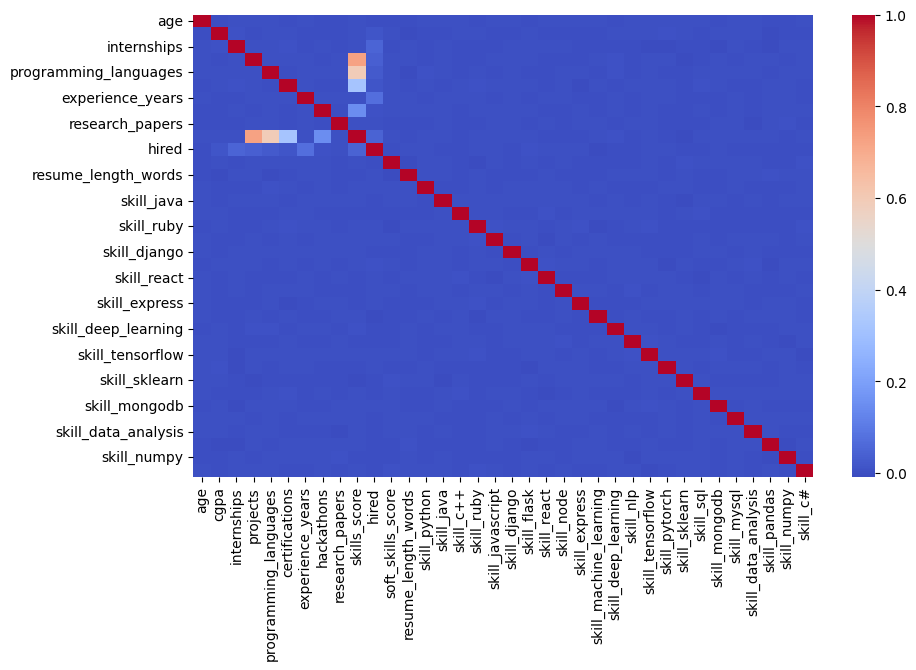

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

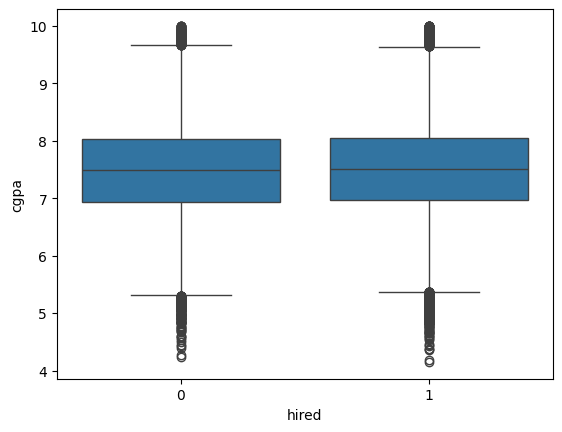

In [72]:
sns.boxplot(x='hired', y='cgpa', data=df)
plt.show()

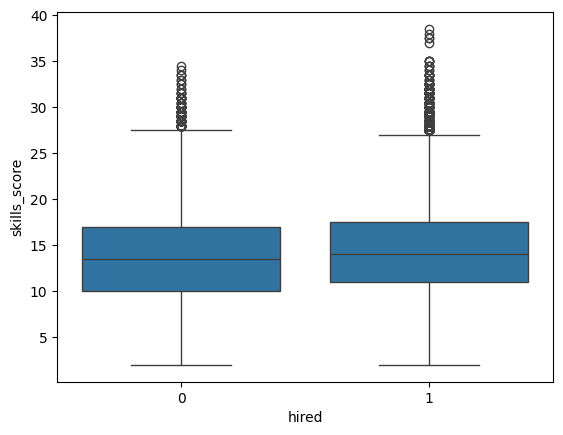

In [73]:
sns.boxplot(x='hired', y='skills_score', data=df)
plt.show()

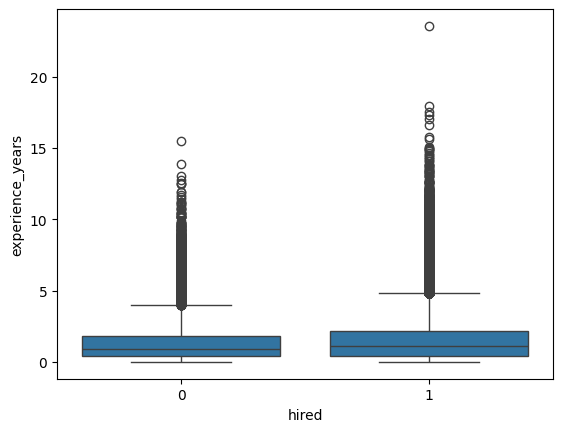

In [74]:
sns.boxplot(x='hired', y='experience_years', data=df)
plt.show()

In [75]:
le = LabelEncoder()
df['education_level'] = le.fit_transform(df['education_level'])

df = pd.get_dummies(df, columns=['university_tier', 'company_type'], drop_first=True)

In [76]:
df.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#,university_tier_Tier 2,university_tier_Tier 3,company_type_Mid-size,company_type_Startup
0,27,0,8.16,2,7,2,2,0.33,0,0,...,1,1,1,1,1,0,True,False,False,False
1,24,0,6.35,3,2,2,2,4.99,0,0,...,0,1,0,1,1,0,False,True,False,True
2,33,0,7.78,0,2,4,2,0.93,0,0,...,1,0,1,1,1,1,False,True,False,True
3,31,1,6.92,2,1,4,1,0.37,0,0,...,0,0,1,0,1,0,False,True,False,False
4,28,1,8.24,3,0,1,2,0.33,0,0,...,1,0,1,1,1,1,True,False,True,False


In [77]:
X = df.drop(columns=['hired'])
y = df['hired']

In [78]:
X.shape

(199799, 40)

In [79]:
X.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#,university_tier_Tier 2,university_tier_Tier 3,company_type_Mid-size,company_type_Startup
0,27,0,8.16,2,7,2,2,0.33,0,0,...,1,1,1,1,1,0,True,False,False,False
1,24,0,6.35,3,2,2,2,4.99,0,0,...,0,1,0,1,1,0,False,True,False,True
2,33,0,7.78,0,2,4,2,0.93,0,0,...,1,0,1,1,1,1,False,True,False,True
3,31,1,6.92,2,1,4,1,0.37,0,0,...,0,0,1,0,1,0,False,True,False,False
4,28,1,8.24,3,0,1,2,0.33,0,0,...,1,0,1,1,1,1,True,False,True,False


In [80]:
X.dtypes

age                         int64
education_level             int64
cgpa                      float64
internships                 int64
projects                    int64
programming_languages       int64
certifications              int64
experience_years          float64
hackathons                  int64
research_papers             int64
skills_score              float64
soft_skills_score         float64
resume_length_words         int64
skill_python                int32
skill_java                  int32
skill_c++                   int32
skill_ruby                  int32
skill_javascript            int32
skill_django                int32
skill_flask                 int32
skill_react                 int32
skill_node                  int32
skill_express               int32
skill_machine_learning      int32
skill_deep_learning         int32
skill_nlp                   int32
skill_tensorflow            int32
skill_pytorch               int32
skill_sklearn               int32
skill_sql     

In [81]:
X = X.astype(float)

In [82]:
X.dtypes

age                       float64
education_level           float64
cgpa                      float64
internships               float64
projects                  float64
programming_languages     float64
certifications            float64
experience_years          float64
hackathons                float64
research_papers           float64
skills_score              float64
soft_skills_score         float64
resume_length_words       float64
skill_python              float64
skill_java                float64
skill_c++                 float64
skill_ruby                float64
skill_javascript          float64
skill_django              float64
skill_flask               float64
skill_react               float64
skill_node                float64
skill_express             float64
skill_machine_learning    float64
skill_deep_learning       float64
skill_nlp                 float64
skill_tensorflow          float64
skill_pytorch             float64
skill_sklearn             float64
skill_sql     

In [83]:
X.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,skill_mongodb,skill_mysql,skill_data_analysis,skill_pandas,skill_numpy,skill_c#,university_tier_Tier 2,university_tier_Tier 3,company_type_Mid-size,company_type_Startup
0,27.0,0.0,8.16,2.0,7.0,2.0,2.0,0.33,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,24.0,0.0,6.35,3.0,2.0,2.0,2.0,4.99,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2,33.0,0.0,7.78,0.0,2.0,4.0,2.0,0.93,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0
3,31.0,1.0,6.92,2.0,1.0,4.0,1.0,0.37,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,28.0,1.0,8.24,3.0,0.0,1.0,2.0,0.33,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0


In [84]:
print(X.shape)
print(y.shape)

(199799, 40)
(199799,)


In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [87]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [88]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5178178178178178
              precision    recall  f1-score   support

           0       0.32      0.59      0.42     11680
           1       0.74      0.49      0.59     28280

    accuracy                           0.52     39960
   macro avg       0.53      0.54      0.50     39960
weighted avg       0.62      0.52      0.54     39960



In [89]:
import numpy as np
from sklearn.metrics import f1_score

probs = model.predict_proba(X_test)[:,1]

thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

for t in thresholds:
    y_pred = (probs > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    print(f"Threshold: {t}, F1 Score: {f1}")


              precision    recall  f1-score   support

           0       0.33      0.01      0.02     11680
           1       0.71      0.99      0.83     28280

    accuracy                           0.70     39960
   macro avg       0.52      0.50      0.43     39960
weighted avg       0.60      0.70      0.59     39960

Threshold: 0.4, F1 Score: 0.8254956337030918
              precision    recall  f1-score   support

           0       0.34      0.21      0.26     11680
           1       0.72      0.83      0.77     28280

    accuracy                           0.65     39960
   macro avg       0.53      0.52      0.52     39960
weighted avg       0.61      0.65      0.62     39960

Threshold: 0.45, F1 Score: 0.7719097074337385
              precision    recall  f1-score   support

           0       0.32      0.59      0.42     11680
           1       0.74      0.49      0.59     28280

    accuracy                           0.52     39960
   macro avg       0.53      0.54    

In [90]:
probs = model.predict_proba(X_test)[:,1]
y_pred = (probs > 0.45).astype(int)

In [91]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.21      0.26     11680
           1       0.72      0.83      0.77     28280

    accuracy                           0.65     39960
   macro avg       0.53      0.52      0.52     39960
weighted avg       0.61      0.65      0.62     39960



In [92]:
print(y_pred[:20])
print(probs[:20])

[1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1]
[0.47857686 0.46911739 0.49539652 0.472141   0.49485037 0.53212512
 0.51275426 0.43271553 0.49676664 0.4860781  0.52726411 0.54602087
 0.56298508 0.63491511 0.52674951 0.50427065 0.589456   0.50675941
 0.42863025 0.46931487]


In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6515515515515515


In [94]:
import joblib

joblib.dump(model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

with open('../models/threshold.txt', 'w') as f:
    f.write("0.45")

In [95]:
import json

with open('../models/columns.json', 'w') as f:
    json.dump(list(X.columns), f)